## MARL для динамического ценообразования (X5, Магнит, Лента)

### 1. Подготовка окружения
   - импорт библиотек
   - настройка random seed для воспроизводимости

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import torch.nn.functional as F

In [2]:
# seed для воспроизводимости результата
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# параметры отображения графиков
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### 2. Загрузка и калибровка данных из Excel
   - чтение файла Ритейл_РФ_2021_2024.xlsx
   - извлечение параметров для X5, Магнит, Лента за 2024 год
   - расчёт издержек, долей рынка, волатильности

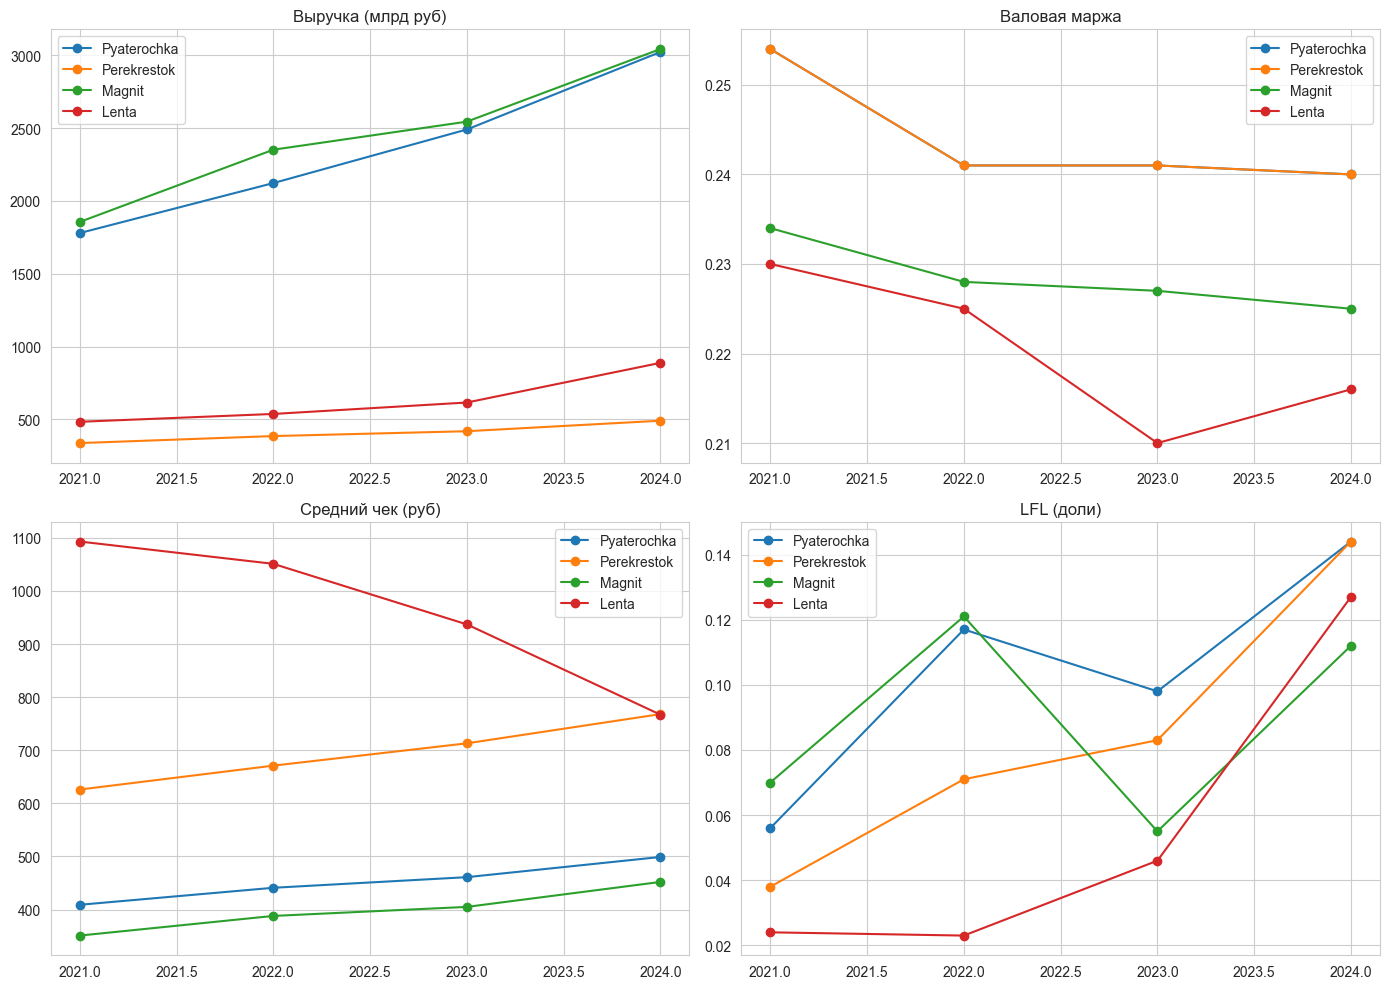

In [3]:
data = {
    'Pyaterochka': {
        'revenue': {2021: 1779.6, 2022: 2122.8, 2023: 2491.0, 2024: 3023.0},
        'margin':  {2021: 0.254, 2022: 0.241, 2023: 0.241, 2024: 0.240},
        'avg_check': {2021: 409, 2022: 441, 2023: 461, 2024: 499},
        'lfl':      {2021: 0.056, 2022: 0.117, 2023: 0.098, 2024: 0.144}
    },
    'Perekrestok': {
        'revenue': {2021: 337.4, 2022: 385.5, 2023: 418.9, 2024: 491.0},
        'margin':  {2021: 0.254, 2022: 0.241, 2023: 0.241, 2024: 0.240},
        'avg_check': {2021: 626, 2022: 671, 2023: 713, 2024: 768},
        'lfl':      {2021: 0.038, 2022: 0.071, 2023: 0.083, 2024: 0.144}
    },
    'Magnit': {
        'revenue': {2021: 1856.1, 2022: 2352.0, 2023: 2544.7, 2024: 3043.4},
        'margin':  {2021: 0.234, 2022: 0.228, 2023: 0.227, 2024: 0.225},
        'avg_check': {2021: 351, 2022: 388, 2023: 405, 2024: 452},
        'lfl':      {2021: 0.070, 2022: 0.121, 2023: 0.055, 2024: 0.112}
    },
    'Auchan': {
        'revenue': {2021: 229.0, 2022: 237.2, 2023: 226.0, 2024: 278.0},  
        'margin':  {2021: 0.290, 2022: 0.301, 2023: 0.298, 2024: None},   
        'avg_check': {2021: None, 2022: 902.5, 2023: 963, 2024: None},    
        'lfl':      {2021: None, 2022: None, 2023: None, 2024: None}      
    },
    'Lenta': {
        'revenue': {2021: 483.6, 2022: 537.4, 2023: 615.9, 2024: 888.3},
        'margin':  {2021: 0.230, 2022: 0.225, 2023: 0.210, 2024: 0.216},
        'avg_check': {2021: 1093, 2022: 1051, 2023: 937, 2024: 767},
        'lfl':      {2021: 0.024, 2022: 0.023, 2023: 0.046, 2024: 0.127}
    }
}
    
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['revenue', 'margin', 'avg_check', 'lfl']
titles = ['Выручка (млрд руб)', 'Валовая маржа', 'Средний чек (руб)', 'LFL (доли)']

for idx, metric in enumerate(metrics):
    ax = axes[idx//2, idx%2]
    for company in ['Pyaterochka', 'Perekrestok', 'Magnit', 'Lenta']:
        years = sorted(data[company][metric].keys())
        values = [data[company][metric][y] for y in years]
        ax.plot(years, values, marker='o', label=company)
    ax.set_title(titles[idx])
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

In [4]:
x5_data = {
    'revenue': {},
    'margin': {},
    'avg_check': {},
    'lfl': {}
}

for year in [2021, 2022, 2023, 2024]:
    rev_pyat = data['Pyaterochka']['revenue'][year]
    rev_perek = data['Perekrestok']['revenue'][year]
    x5_data['revenue'][year] = rev_pyat + rev_perek
    
    # средневзвешенная маржа
    margin_pyat = data['Pyaterochka']['margin'][year]
    margin_perek = data['Perekrestok']['margin'][year]
    x5_data['margin'][year] = (rev_pyat * margin_pyat + rev_perek * margin_perek) / (rev_pyat + rev_perek)
    
    # средневзвешенный чек
    check_pyat = data['Pyaterochka']['avg_check'][year]
    check_perek = data['Perekrestok']['avg_check'][year]
    x5_data['avg_check'][year] = (rev_pyat * check_pyat + rev_perek * check_perek) / (rev_pyat + rev_perek)
    
    # LFL (среднее арифметическое)
    lfl_pyat = data['Pyaterochka']['lfl'][year]
    lfl_perek = data['Perekrestok']['lfl'][year]
    x5_data['lfl'][year] = (lfl_pyat + lfl_perek) / 2

data['X5'] = x5_data

### 3. Определение параметров среды (OligopolyMarketEnv)
   - перенос класса среды (можно скопировать из предоставленного кода)
   - задание конфигурации (число агентов, цены, μ, шум, частичная наблюдаемость)

In [5]:
class OligopolyMarketEnv:
    """
    Многоагентная среда с динамическим спросом (через ОДУ)
    """

    def __init__(self, 
                 n_firms=3,
                 marginal_costs=None,
                 quality_params=[1.0, 1.0, 1.0],
                 mu=0.2,
                 a0=0.0,
                 price_min=300,
                 price_max=800,
                 n_price_levels=15,
                 demand_noise=0.03,
                 market_size=1000,
                 partial_obs=False,
                 alpha_demand=0.0,  
                 dt=1.0):           
        
        self.n_firms = n_firms
        self.mu = mu
        self.a0 = a0
        self.demand_noise = demand_noise
        self.partial_obs = partial_obs
        self.market_size = market_size

        self.alpha_demand = alpha_demand
        self.dt = dt

        # издержки
        if marginal_costs is None:
            self.marginal_costs = [200.0] * n_firms
        else:
            self.marginal_costs = marginal_costs
        
        # качества
        if quality_params is None:
            self.quality_params = [1.0] * n_firms
        else:
            self.quality_params = quality_params

        # цены
        self.price_levels = np.linspace(price_min, price_max, n_price_levels)
        self.action_space = n_price_levels
        self.action_space_n = [n_price_levels] * n_firms

        # наблюдения
        if partial_obs:
            self.observation_dim = 2
        else:
            self.observation_dim = n_firms + 1

        self.reset()

    def reset(self):
        self.current_prices = np.random.choice(self.price_levels, self.n_firms)

        # "динамический спрос"
        self.current_demand = np.ones(self.n_firms) * (self.market_size / self.n_firms)

        self.last_sales = np.zeros(self.n_firms)
        self.current_step = 0
        return self._get_observations()

    def step(self, actions):

        prices = np.array([self.price_levels[a] for a in actions])
        self.current_prices = prices

        # целевой спрос (logit)
        target_demand = self._compute_demand(prices)

        # обновление через ОДУ
        self.current_demand = self._update_demand(self.current_demand, target_demand)

        # добавляем шум
        sales = self.current_demand.copy()
        if self.demand_noise > 0:
            noise = np.random.normal(1.0, self.demand_noise, self.n_firms)
            sales = sales * noise
            sales = np.maximum(sales, 0)

        self.last_sales = sales

        # прибыль
        profits = (prices - self.marginal_costs) * sales

        next_obs = self._get_observations()

        self.current_step += 1
        done = False

        info = {
            'prices': prices,
            'sales': sales,
            'profits': profits
        }

        return next_obs, profits.tolist(), done, info

    def _compute_demand(self, prices):
        numerators = np.exp((self.quality_params - prices) / self.mu)
        denominator = np.sum(numerators) + np.exp(self.a0 / self.mu)
        shares = numerators / denominator
        return shares * self.market_size

    def _update_demand(self, q, D):
        """
        Дискретизация ОДУ:
        q_{t+1} = q_t + alpha * (D - q_t) * dt
        """
        return q + self.alpha_demand * (D - q) * self.dt

    def _get_observations(self):
        obs = []
        if self.partial_obs:
            for i in range(self.n_firms):
                obs_i = np.array([
                    self.current_prices[i] / 100.0,
                    self.last_sales[i] / self.market_size
                ])
                obs.append(obs_i)
        else:
            norm_prices = self.current_prices / 100.0
            norm_avg_sales = np.mean(self.last_sales) / self.market_size
            global_obs = np.concatenate([norm_prices, [norm_avg_sales]])
            obs = [global_obs.copy() for _ in range(self.n_firms)]
        return obs

In [6]:
class DQNNetwork(nn.Module):
    """Простая полносвязная нейросеть для аппроксимации Q-функции"""
    def __init__(self, state_dim, action_dim, hidden_sizes=[64, 64]):
        super(DQNNetwork, self).__init__()
        layers = []
        prev_size = state_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            prev_size = h
        layers.append(nn.Linear(prev_size, action_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [7]:
class ReplayBuffer:
    """Буфер для хранения и сэмплирования опыта (state, action, reward, next_state, done)"""
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        """Сохраняет один переход."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Возвращает случайный мини-батч переходов."""
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states),
                np.array(actions),
                np.array(rewards),
                np.array(next_states),
                np.array(dones))

    def __len__(self):
        return len(self.buffer)

In [8]:
class DQNAgent:
    """
    DQN-агент с буфером воспроизведения, target-сетью и epsilon-жадной стратегией
    """
    def __init__(self,
                 agent_id,
                 state_dim,
                 action_dim,
                 hidden_sizes=[64, 64],
                 learning_rate=1e-4,
                 gamma=0.99,
                 epsilon_start=1.0,
                 epsilon_end=0.05,
                 epsilon_decay=0.998,
                 buffer_size=100000,
                 batch_size=128,
                 target_update_freq=200,
                 device='cpu'):

        self.agent_id = agent_id
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.device = device
        self.step_count = 0

        # Основная и target-сети
        self.q_network = DQNNetwork(state_dim, action_dim, hidden_sizes).to(device)
        self.target_network = DQNNetwork(state_dim, action_dim, hidden_sizes).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.replay_buffer = ReplayBuffer(buffer_size)

    def act(self, state, eval_mode=False):
        """
        Выбор действия согласно epsilon-жадной стратегии
        eval_mode=True отключает exploration
        """
        if not eval_mode and np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
            action = torch.argmax(q_values, dim=1).item()
        return action

    def update(self):
        """Обновление Q-сети на основе сэмплированного батча"""
        if len(self.replay_buffer) < self.batch_size:
            return 0.0

        # сэмплируем батч
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)

        # конвертируем в тензоры
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        # текущие Q-значения
        current_q = self.q_network(states).gather(1, actions)

        # целевые Q-значения (Double DQN)
        with torch.no_grad():
            next_actions = self.q_network(next_states).argmax(dim=1, keepdim=True)
            next_q = self.target_network(next_states).gather(1, next_actions)
            target_q = rewards + (1 - dones) * self.gamma * next_q

        # вычисляем loss
        loss = nn.MSELoss()(current_q, target_q)

        # оптимизация
        self.optimizer.zero_grad()
        loss.backward()
        # градиентное отсечение для стабильности
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
        self.optimizer.step()

        # обновляем target-сеть
        self.step_count += 1
        if self.step_count % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

        # затухание epsilon
        # self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

        return loss.item()

    def remember(self, state, action, reward, next_state, done):
        """Сохранить переход в буфер"""
        self.replay_buffer.add(state, action, reward, next_state, done)

In [9]:
env = OligopolyMarketEnv(
    n_firms=3,
    marginal_costs=[320, 280, 400],  # X5, Magnit, Lenta
    quality_params=[1.0, 1.0, 1.0],
    alpha_demand=0.3,
    demand_noise=0.03,
    partial_obs=False
)

agents = [
    DQNAgent(
        agent_id=i,
        state_dim=env.observation_dim,
        action_dim=env.action_space
    )
    for i in range(env.n_firms)
]

num_episodes = 1500
steps_per_episode = 200

price_history = []
profit_history = []

for episode in range(num_episodes):

    states = env.reset()

    for step in range(steps_per_episode):

        # действия
        actions = [agents[i].act(states[i]) for i in range(env.n_firms)]

        # шаг среды
        next_states, rewards, done, info = env.step(actions)

        # обучение
        for i in range(env.n_firms):
            agents[i].remember(states[i], actions[i], rewards[i], next_states[i], done)
            agents[i].update()

        states = next_states

        # логирование 
        price_history.append(info['prices'])
        profit_history.append(info['profits'])

    for agent in agents:
        agent.epsilon = max(agent.epsilon_end, agent.epsilon * agent.epsilon_decay)

    if episode % 50 == 0:
        print(f"Episode {episode}, epsilon={agents[0].epsilon:.3f}")

Episode 0, epsilon=0.998
Episode 50, epsilon=0.903
Episode 100, epsilon=0.817
Episode 150, epsilon=0.739
Episode 200, epsilon=0.669
Episode 250, epsilon=0.605
Episode 300, epsilon=0.547
Episode 350, epsilon=0.495
Episode 400, epsilon=0.448
Episode 450, epsilon=0.405
Episode 500, epsilon=0.367
Episode 550, epsilon=0.332
Episode 600, epsilon=0.300
Episode 650, epsilon=0.272
Episode 700, epsilon=0.246
Episode 750, epsilon=0.222
Episode 800, epsilon=0.201
Episode 850, epsilon=0.182
Episode 900, epsilon=0.165
Episode 950, epsilon=0.149
Episode 1000, epsilon=0.135
Episode 1050, epsilon=0.122
Episode 1100, epsilon=0.110
Episode 1150, epsilon=0.100
Episode 1200, epsilon=0.090
Episode 1250, epsilon=0.082
Episode 1300, epsilon=0.074
Episode 1350, epsilon=0.067
Episode 1400, epsilon=0.061
Episode 1450, epsilon=0.055


In [10]:
price_history = np.array(price_history)
profit_history = np.array(profit_history)

last_steps = min(200, len(price_history))
prices_last = price_history[-last_steps:]
profits_last = profit_history[-last_steps:]

# средние цены и прибыль по фирмам
avg_prices = np.mean(prices_last, axis=0)
avg_profits = np.mean(profits_last, axis=0)

# предельные издержки (они у вас заданы в среде)
costs = env.marginal_costs

# вывод
print("Результаты эксперимента (mu=0.2)")
print(f"Количество шагов: {len(price_history)}")
print(f"Усреднение по последним {last_steps} шагам")
print()
for i, firm in enumerate(['X5', 'Magnit', 'Lenta']):
    print(f"Фирма {firm}:")
    print(f"  Средняя цена: {avg_prices[i]:.2f} руб.")
    print(f"  Предельные издержки: {costs[i]:.2f} руб.")
    print(f"  Отклонение от издержек: {avg_prices[i] - costs[i]:.2f} руб. ({(avg_prices[i] - costs[i])/costs[i]*100:.1f}%)")
    print(f"  Средняя прибыль за шаг: {avg_profits[i]:.2f}")
    print()

print("Волатильность цен (последние 200 шагов)")
for i, firm in enumerate(['X5', 'Magnit', 'Lenta']):
    print(f"{firm}: {np.std(prices_last[:, i]):.2f} руб.")

# сравнение с равновесием Бертрана (цена = издержки)
bertrand_deviation = np.mean(avg_prices - costs)
print(f"\nСреднее отклонение от равновесия Бертрана: {bertrand_deviation:.2f} руб.")

=== Результаты эксперимента (mu=0.2) ===
Количество шагов: 300000
Усреднение по последним 200 шагам

Фирма X5:
  Средняя цена: 751.43 руб.
  Предельные издержки: 320.00 руб.
  Отклонение от издержек: 431.43 руб. (134.8%)
  Средняя прибыль за шаг: 1698.72

Фирма Magnit:
  Средняя цена: 764.11 руб.
  Предельные издержки: 280.00 руб.
  Отклонение от издержек: 484.11 руб. (172.9%)
  Средняя прибыль за шаг: 1911.85

Фирма Lenta:
  Средняя цена: 749.82 руб.
  Предельные издержки: 400.00 руб.
  Отклонение от издержек: 349.82 руб. (87.5%)
  Средняя прибыль за шаг: 1393.67

=== Волатильность цен (последние 200 шагов) ===
X5: 62.99 руб.
Magnit: 55.27 руб.
Lenta: 74.92 руб.

Среднее отклонение от равновесия Бертрана: 421.79 руб.


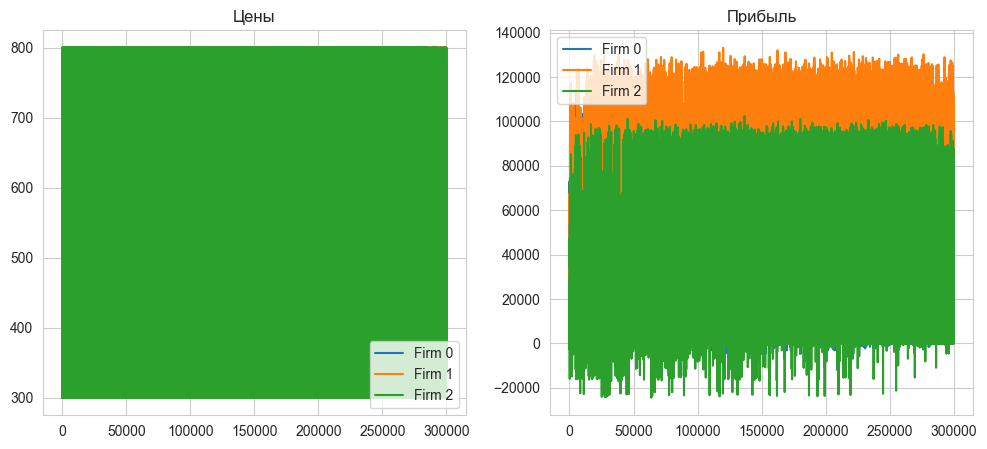

In [11]:
price_history = np.array(price_history)
profit_history = np.array(profit_history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i in range(3):
    plt.plot(price_history[:, i], label=f'Firm {i}')
plt.title("Цены")
plt.legend()

plt.subplot(1, 2, 2)
for i in range(3):
    plt.plot(profit_history[:, i], label=f'Firm {i}')
plt.title("Прибыль")
plt.legend()

plt.show()

In [12]:
avg_checks = [541.5, 452.0, 767.0]      # X5, Magnit, Lenta
market_shares = [0.472, 0.409, 0.119]   # доли рынка

mu = 0.5
log_shares = np.log(market_shares)
alpha = avg_checks + mu * log_shares

# Опционально: центрируем, чтобы значения не были слишком большими
alpha = alpha - np.mean(alpha)

print("Новые α_i:", alpha)

Новые α_i: [ -45.07981345 -134.65144536  179.73125881]
